In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [4]:
df = pd.read_csv('../data/creditcard.csv', delimiter=',')
print("Shape:", df.shape)
print("Columns:", df.columns)

X = df.drop(['Class'], axis=1)
y = df['Class']

Shape: (284807, 31)
Columns: Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [ ]:
undersample = RandomUnderSampler(random_state=42)
X_train_undersample, y_train_undersample = undersample.fit_resample(X_train, y_train)


In [10]:
df_train_smote = pd.DataFrame(X_train_smote, columns=X.columns)
df_train_smote['Class'] = y_train_smote

df_train_undersample = pd.DataFrame(X_train_undersample, columns=X.columns)
df_train_undersample['Class'] = y_train_undersample

df_train_original = X_train.copy()
df_train_original['Class'] = y_train


In [ ]:
corr_original = df_train_original.corr()
corr_smote = df_train_smote.corr()
corr_undersample = df_train_undersample.corr()


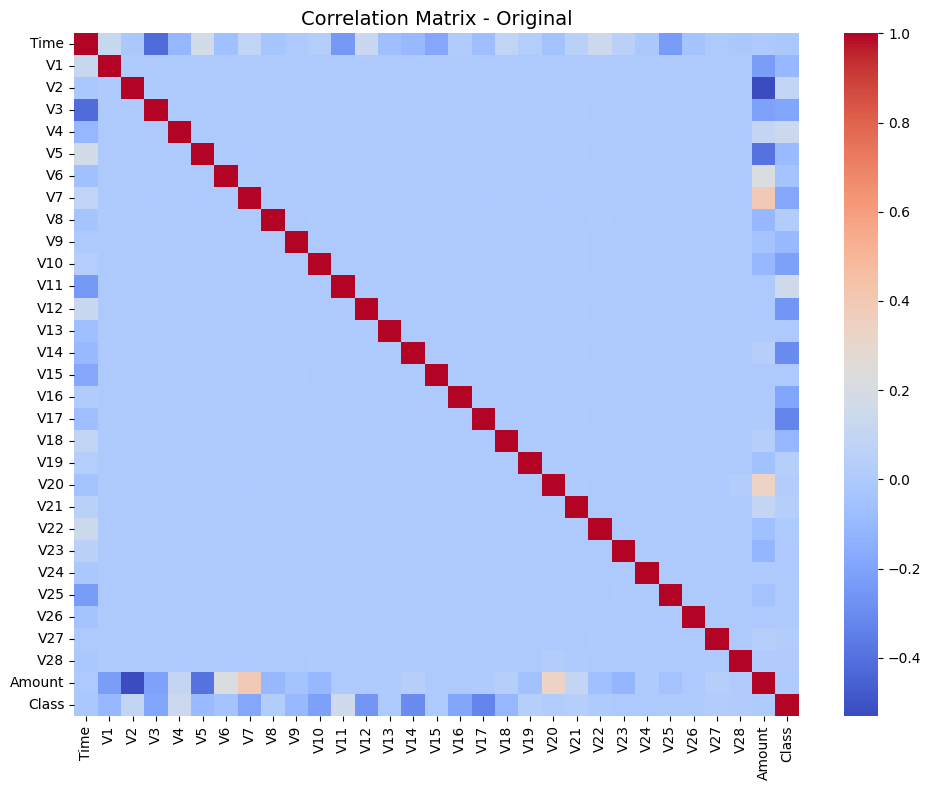

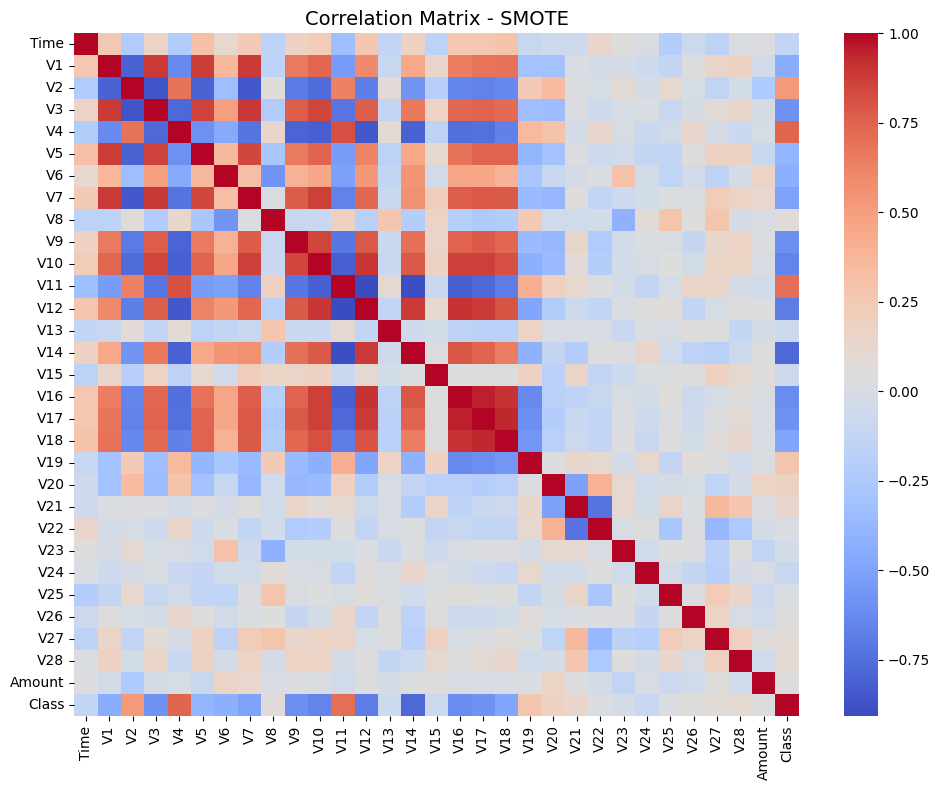

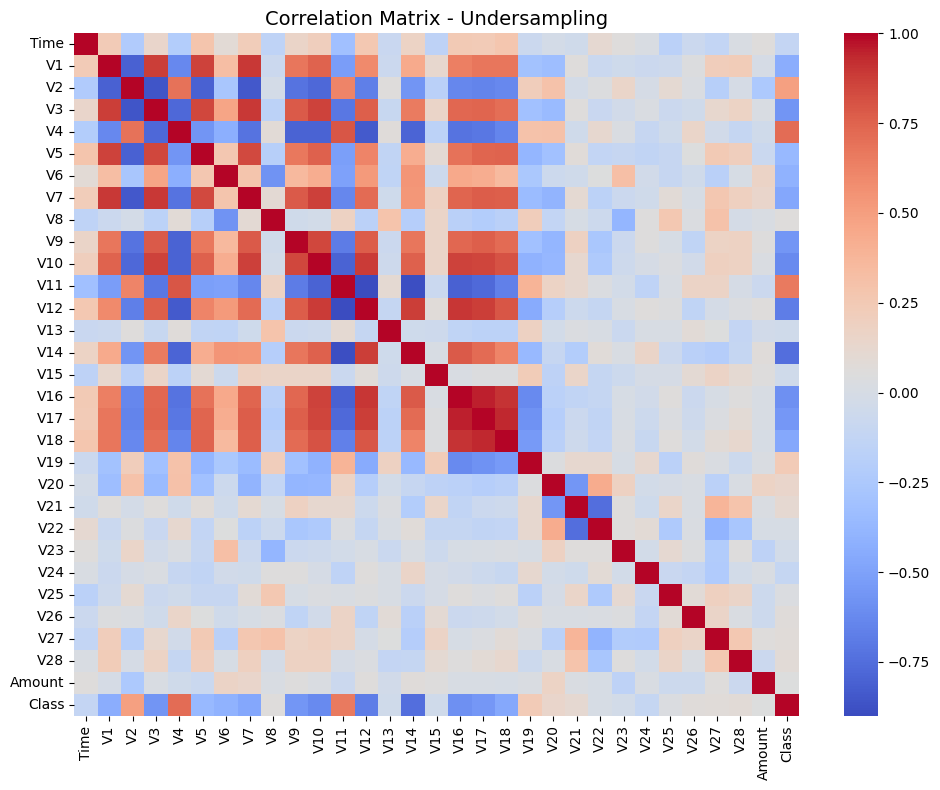

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_original, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix - Original', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_smote, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix - SMOTE', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_undersample, cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix - Undersampling', fontsize=14)
plt.tight_layout()
plt.show()
